
---

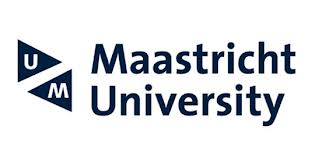

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing (KEN4259) - Tutorial on Multimodal Processing
By: Gijs Wijngaard

---

Version 2026-2027

---

Welcome to this tutorial on Multimodal Processing in NLP. In this notebook, we explore how to combine visual and textual information using modern deep learning architectures.

We will work with **CLIP** (Contrastive Language-Image Pretraining) by OpenAI, which learns a joint embedding space for images and text. We then use CLIP for zero-shot image classification and multimodal disambiguation, and finally build an image captioning model that combines CLIP (as visual encoder) with GPT-2 (as text decoder).

The first step is to enable GPU. A GPU is a Graphical Processing Unit, capable of calculating vectors and matrices much faster than CPU units. Since neural networks are basically made out of matrices, we gain serious speed improvements by using GPUs.

We enable the GPU by clicking on Runtime in the menu above, then click Change runtime type. Make sure the Runtime type is set to Python 3 and under Hardware accelerator click T4 GPU. Then press Save. If the following code returns True, you know that you are using the GPU currently.

⏱️ **Estimated time:** 1.4 hours – 3.0 hours

## Learning Goals

After completing this tutorial, you will be able to:

- **Understand** what multimodal processing is and why combining modalities improves NLP tasks.
- **Explain** how CLIP uses contrastive learning to align image and text embeddings in a shared space.
- **Apply** CLIP for zero-shot image classification and compute image-text similarity scores.
- **Demonstrate** how visual context can disambiguate word meanings in NLP (multimodal disambiguation).
- **Understand** the architecture of an image captioning model that combines a vision encoder (CLIP/ViT) with a text decoder (GPT-2).
- **Distinguish** between early fusion, late fusion, and cross-attention fusion strategies for multimodal models.
- **Evaluate** image captioning quality using metrics like BLEU and CLIPScore.

# What is Multimodality?

**Multimodality** means having more than one modality — a modality being a particular way of encoding information (text, image, audio, video, etc.). As humans, we are inherently multimodal: we see, hear, read, and feel simultaneously.

In NLP and AI, multimodal models combine information from different modalities to achieve better understanding. For example:

| Task | Input Modalities | Output |
|---|---|---|
| Image Captioning | Image → Text | "A dog playing in the park" |
| Visual Question Answering (VQA) | Image + Text → Text | Q: "What color is the car?" A: "Red" |
| Text-to-Image Generation | Text → Image | DALL-E, Stable Diffusion |
| Multimodal Sentiment Analysis | Text + Image → Label | Positive / Negative |

**Why does multimodality matter for NLP?**

Text alone is often ambiguous. The word "bank" can mean a financial institution or a river bank — but an accompanying image immediately disambiguates. Similarly, sarcasm detection improves dramatically when we can see facial expressions alongside text.

## Multimodal Architectures

There are three main approaches for combining modalities:

1. **Encoder-Decoder models**: A modality-specific encoder (e.g., ViT for images) produces embeddings that are fed to a decoder (e.g., GPT-2 for text generation). Used in image captioning.

2. **Contrastive models** (e.g., CLIP): Separate encoders for each modality are trained to produce embeddings in a shared space, where matching pairs are close and non-matching pairs are far apart. Uses the **InfoNCE loss** function.

3. **Decoder-only models** (e.g., GPT-4V, Gemini): A single large model processes multiple modalities through tokenization (images are split into patches/tokens alongside text tokens).

**Fusion strategies** determine *when* modalities are combined:
- **Early fusion**: Combine raw inputs before any processing
- **Late fusion**: Process each modality independently, combine at decision level
- **Cross-attention fusion**: One modality attends to another during processing (most common in transformers)

## Part 1: Using CLIP

First, let's ensure we have access to a GPU.

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
!nvidia-smi

Next, let's import necessary libraries and load the CLIP model

In [ ]:
import importlib, subprocess, sys
to_install = []
if importlib.util.find_spec('clip') is None:
    to_install.append("git+https://github.com/openai/CLIP.git")
if importlib.util.find_spec('transformers') is None:
    to_install.append("transformers==4.28.1")
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])


In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
from PIL import Image
import requests
from io import BytesIO
import clip
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)

Now, let's get an example image and some text prompts.

In [ ]:
# Let's load an random dog example image from the internet
image_url = "https://dog.ceo/api/breeds/image/random"
response = requests.get(requests.get(image_url).json()["message"])
image = Image.open(BytesIO(response.content)).convert("RGB")

display(image)

In [ ]:
# Preprocess the image
image_input = preprocess(image).unsqueeze(0).to(device)

# Define text prompts
labels = ["a diagram", "a dog", "a cat", "a bird"]
text_inputs = torch.cat([clip.tokenize(label) for label in labels]).to(device)

Compute the image and text embeddings.

In [ ]:
with torch.no_grad():
    image_features = clip_model.encode_image(image_input)
    text_features = clip_model.encode_text(text_inputs)

    # Normalize the features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Compute the similarity
    similarities = (image_features @ text_features.T).squeeze(0)

    # Get the most similar text
    values, indices = similarities.topk(1)

Printing the result:

In [ ]:
# Map indices to text labels
print(f"Label: {labels[indices.item()]}, Similarity Score: {values.item():.4f}")

## Part 2: Multimodal disambiguation in NLP
We will now explore how visual context can help disambiguating capabities in NLP.

First, let's consider examples where textual information alone may lead to ambiguity, but combining it with visual information can resolve that ambiguity.

Example:

Let's take the word "bank", which can mean either the edge of a river or a financial institution. Without context, it's unclear which meaning is intended.

In [ ]:
sitting_bank = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSUiyauFKdGdj5mCWWt63PIrxnHuYmfWO_0gg&s"
financial_bank = "https://s3.amazonaws.com/hines-images/chemed-center/chemed-center-with-fountain_hres_web.jpg"
river_bank = "https://assets.plaece.nl/odp-vvvmaastricht/image/maas-sint-servaasbrug-2-maastricht-marketing-hugo-thomassen_3205346874.jpeg"
labels = ["sitting bank", "financial bank", "river bank"]
text_inputs = torch.cat([clip.tokenize(label) for label in labels]).to(device)
text_features = clip_model.encode_text(text_inputs)
text_features /= text_features.norm(dim=-1, keepdim=True)

for bank in [sitting_bank, financial_bank, river_bank]:
    response = requests.get(bank)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    display(image.resize([300, 300]))
    with torch.no_grad():
        image_input = preprocess(image).unsqueeze(0).to(device)
        image_features = clip_model.encode_image(image_input)

        # Normalize the features
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # Compute the similarity
        similarities = (image_features @ text_features.T).squeeze(0)

        # Get the most similar text
        values, indices = similarities.topk(1)
        print(f"Label: {labels[indices.item()]}, Similarity Score: {values.item():.4f}")
        print("\n")

## Part 3: Image Captioning with CLIP and GPT-2

In this part, we will implement a simple image captioning model using a CLIP as the encoder and GPT-2 as the decoder.



In [ ]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from tqdm.notebook import trange
import torch
import torch.nn as nn
import torch.nn.functional as nnf

class MLP(nn.Module):
    def __init__(self, sizes, bias=True, act=nn.Tanh):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(sizes) - 1):
            # Add a linear layer
            layers.append(nn.Linear(sizes[i], sizes[i + 1], bias=bias))
            # Add an activation layer except after the last linear layer
            if i < len(sizes) - 2:
                layers.append(act())
        # Combine all layers into a sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class ClipCaptionModel(nn.Module):
    def __init__(self, prefix_length, prefix_size=512):
        super(ClipCaptionModel, self).__init__()
        self.prefix_length = prefix_length

        # Load a pre-trained GPT-2 language model
        self.gpt = GPT2LMHeadModel.from_pretrained('gpt2')

        # Get the embedding size from GPT-2 model
        self.gpt_embedding_size = self.gpt.transformer.wte.weight.shape[1]

        # Define an MLP to project CLIP embeddings to GPT-2 embedding space
        self.clip_project = MLP(
            sizes=[
                prefix_size,  # Input size (CLIP embedding size)
                (self.gpt_embedding_size * prefix_length) // 2,  # Hidden layer size
                self.gpt_embedding_size * prefix_length  # Output size
            ]
        )

    def forward(self, tokens, prefix, mask=None, labels=None):
        # Get embeddings for the input tokens from GPT-2
        embedding_text = self.gpt.transformer.wte(tokens)

        # Project the CLIP embeddings into GPT-2 embedding space and reshape
        prefix_projections = self.clip_project(prefix).view(
            -1, self.prefix_length, self.gpt_embedding_size
        )

        # Concatenate the projected CLIP embeddings with the token embeddings
        embedding_cat = torch.cat((prefix_projections, embedding_text), dim=1)

        # If labels are provided, adjust them to account for the prefix length
        if labels is not None:
            # Create dummy tokens for the prefix
            dummy_token = torch.zeros(
                tokens.shape[0],
                self.prefix_length,
                dtype=torch.int64,
                device=tokens.device
            )
            # Concatenate dummy tokens with the original labels
            labels = torch.cat((dummy_token, tokens), dim=1)

        # Pass the combined embeddings through GPT-2
        out = self.gpt(
            inputs_embeds=embedding_cat,
            labels=labels,
            attention_mask=mask
        )

        return out

Now let's load pre-trained weights (trained on the COCO dataset) and define the text generation function.

In [ ]:
!gdown --id 1IdaBtMSvtyzF0ByVaBHtvM0JYSXRExRX -c
model = ClipCaptionModel(10)
model.load_state_dict(torch.load("coco_weights.pt", map_location="cpu"))
model = model.eval()
model = model.to(device)

In [ ]:
def generate(
        model,
        tokenizer,
        tokens=None,
        prompt=None,
        embed=None,
        entry_count=1,
        entry_length=67,  # Maximum number of tokens to generate
        top_p=0.8,
        temperature=1.0,
        stop_token='.',
        device="cuda" if torch.cuda.is_available() else "cpu"
):
    # Double check that the model is set to evaluation mode
    model.eval()
    generated_list = []
    # Get the token ID for the stop token
    stop_token_index = tokenizer.encode(stop_token)[0]
    # Value used to filter out tokens
    filter_value = -float("Inf")

    # Disable gradient calculations for efficiency
    with torch.no_grad():
        # Generate 'entry_count' number of outputs
        for _ in trange(entry_count):
            if embed is not None:
                # Use the provided embeddings as the initial input
                generated = embed
            else:
                if tokens is None:
                    # If tokens are not provided, tokenize the prompt
                    tokens = torch.tensor(tokenizer.encode(prompt), dtype=torch.long).unsqueeze(0).to(device)
                # Get the embeddings for the input tokens
                generated = model.gpt.transformer.wte(tokens)

            # Generate tokens up to 'entry_length'
            for _ in range(entry_length):
                # Pass the embeddings through GPT to get the logits
                outputs = model.gpt(inputs_embeds=generated)
                logits = outputs.logits

                # Adjust the logits based on the temperature
                logits = logits[:, -1, :] / (temperature if temperature > 0 else 1.0)

                # Apply nucleus (top-p) sampling
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(nnf.softmax(sorted_logits, dim=-1), dim=-1)

                # Remove tokens with cumulative probability above 'top_p'
                sorted_indices_to_remove = cumulative_probs > top_p
                # Shift the indices to the right to keep the first token
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0

                # Set the logits of unwanted tokens to filter_value
                indices_to_remove = sorted_indices[sorted_indices_to_remove]
                logits[:, indices_to_remove] = filter_value

                # Sample the next token (here using greedy sampling via argmax)
                next_token = torch.argmax(logits, dim=-1).unsqueeze(0)
                # Get the embedding of the next token
                next_token_embed = model.gpt.transformer.wte(next_token)

                # Append the next token to the token sequence
                if tokens is None:
                    tokens = next_token
                else:
                    tokens = torch.cat((tokens, next_token), dim=1)
                # Append the next token's embedding to the generated embeddings
                generated = torch.cat((generated, next_token_embed), dim=1)

                # If the stop token is generated, end the sequence
                if next_token.item() == stop_token_index:
                    break

            # Decode the generated tokens into text
            output_tokens = tokens.squeeze().cpu().numpy()
            output_text = tokenizer.decode(output_tokens)
            generated_list.append(output_text)

    # Return the first generated output
    return generated_list[0]

In [ ]:
# Load the pre-trained GPT-2 tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Disable gradient calculations since we're in inference mode
with torch.no_grad():
    # Encode the input image using the CLIP model to get image embeddings
    prefix = clip_model.encode_image(image_input).to(device, dtype=torch.float32)

    # Project the CLIP image embeddings into the GPT-2 embedding space
    prefix_embed = model.clip_project(prefix).reshape(1, model.prefix_length, -1)

    # Generate text using the model, starting from the projected image embeddings
    generated_text_prefix = generate(model, tokenizer, embed=prefix_embed)

In [ ]:
display(image)
print("Generated caption:", generated_text_prefix)

## CLIP Score: Evaluating Image-Text Alignment

**CLIPScore** is becoming a popular metric for evaluating image-text models. It measures how well a generated caption matches an image by computing the cosine similarity between their CLIP embeddings:

$$\text{CLIPScore}(I, C) = \max(\cos(E_I(I), E_T(C)), 0)$$

where $E_I$ is the CLIP image encoder and $E_T$ is the CLIP text encoder.

**Advantages over BLEU/ROUGE:**
- Does not require reference captions (reference-free)
- Captures semantic similarity rather than n-gram overlap
- Correlates better with human judgments of caption quality

CLIPScore can also be used in a **reference-based** variant (RefCLIPScore) that additionally considers similarity to reference captions.

## Neural Scaling Laws

An important consideration when building multimodal (and any large) models is: **how much data and compute do we need?** Neural scaling laws provide empirical answers.

### The Chinchilla Scaling Law

The original GPT-3 scaling law (Kaplan et al., 2020) suggested that increasing **model size** was more important than increasing **data size**. This led to very large models trained on relatively small datasets.

**Chinchilla** (Hoffmann et al., 2022, DeepMind) overturned this by showing that model size and training data should be scaled **equally**. For a given compute budget, the **compute-optimal** model uses:

$$N_{opt} \propto C^{0.5}, \quad D_{opt} \propto C^{0.5}$$

where $N$ is the number of parameters, $D$ is the number of training tokens, and $C$ is the compute budget (in FLOPs). Roughly: **for every doubling of model size, you should also double the training data.**

| Model | Parameters | Training tokens | Compute-optimal? |
|---|---|---|---|
| GPT-3 | 175B | 300B | ❌ Undertrained (should have used ~3.5T tokens) |
| Chinchilla | 70B | 1.4T | ✅ Same compute as GPT-3, but better performance |
| LLaMA-2 | 70B | 2T | ✅ Overtrained for inference efficiency |

### Test-Time Compute Scaling

A more recent development is **test-time compute scaling** (2024-2025): instead of only scaling training, you can also scale the compute used *at inference time*:

- **Chain-of-thought** and **tree-of-thought** prompting let the model "think longer"
- **Self-consistency** generates multiple reasoning paths and votes on the answer
- **Beam search** with verification explores multiple solutions

OpenAI's o1 model demonstrated that scaling test-time compute can sometimes substitute for scaling training compute, achieving better performance on reasoning tasks by spending more computation during inference.

### Implications for Multimodal Models

Scaling laws apply across modalities. CLIP was trained on 400M image-text pairs; larger datasets (LAION-5B with 5.8B pairs) yielded better CLIP variants. The key insight is that **data quality and quantity both matter** — a smaller, cleaner dataset can outperform a larger, noisier one.

---

# Exercises

Complete the following four exercises. Write your code in the code cells and your explanations in the markdown cells. Use the `### BEGIN SOLUTION` and `### END SOLUTION` markers to indicate your solutions.

## Exercise A1: CLIP Zero-Shot Classification (15 points)

**a)** (5 points - code) The CLIP classification scaffold is provided below (same pattern as the tutorial). Add **3 different images** (not the dog from the tutorial), each with at least 5 candidate labels. Store results in `classification_results`.

**b)** (10 points - explanation) How does CLIP perform zero-shot classification without task-specific training? Explain the role of contrastive learning and why we normalize feature vectors before computing similarity.

In [ ]:
# CLIP classification scaffold (provided — same pattern as tutorial)
import torch, requests
from PIL import Image
from io import BytesIO

def classify_image(image_url, labels):
    response = requests.get(image_url, timeout=10)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    image_input = preprocess(img).unsqueeze(0).to(device)
    text_inputs = torch.cat([clip.tokenize(l) for l in labels]).to(device)
    with torch.no_grad():
        img_feat = clip_model.encode_image(image_input)
        txt_feat = clip_model.encode_text(text_inputs)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)
        txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
        sims = (img_feat @ txt_feat.T).squeeze().cpu().numpy()
    ranked = sorted(zip(labels, sims.tolist()), key=lambda x: -x[1])
    return {"image_url": image_url,
            "top_labels": [r[0] for r in ranked[:3]],
            "top_scores": [r[1] for r in ranked[:3]]}

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A1 (5 points)
assert 'classification_results' in dir(), "classification_results must be defined"
assert isinstance(classification_results, list), "classification_results must be a list"
assert len(classification_results) >= 3, "Must classify at least 3 images"
for r in classification_results:
    assert "image_url" in r, "Each result must have 'image_url'"
    assert "top_labels" in r, "Each result must have 'top_labels'"
    assert "top_scores" in r, "Each result must have 'top_scores'"
    assert len(r["top_labels"]) >= 3, "Must have at least 3 top labels"
    assert all(isinstance(s, float) for s in r["top_scores"]), "Scores must be floats"
    assert r["top_scores"][0] >= r["top_scores"][1], "Scores must be sorted descending"
print("All A1 tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Multimodal Disambiguation (15 points)

**a)** (5 points - code) The scaffold below uses CLIP for disambiguation. Choose a **different homonym** than "bank" (e.g., "bat", "crane", "spring", "mouse") and provide URLs for at least 3 images representing different meanings. Store results in `disambiguation_results`.

**b)** (10 points - explanation) How does visual context disambiguate homonyms? Give **one** additional real-world scenario where combining visual and textual modalities improves NLP performance.

In [ ]:
# Disambiguation scaffold (provided)
def disambiguate(image_url, intended_meaning, candidate_labels):
    result = classify_image(image_url, candidate_labels)
    predicted = result["top_labels"][0]
    return {"image_meaning": intended_meaning,
            "predicted_label": predicted,
            "correct": intended_meaning.lower() in predicted.lower()}

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A2 (5 points)
assert 'disambiguation_results' in dir(), "disambiguation_results must be defined"
assert isinstance(disambiguation_results, list), "disambiguation_results must be a list"
assert len(disambiguation_results) >= 3, "Must test at least 3 images"
for r in disambiguation_results:
    assert "image_meaning" in r, "Each result must have 'image_meaning'"
    assert "predicted_label" in r, "Each result must have 'predicted_label'"
    assert "correct" in r, "Each result must have 'correct'"
    assert isinstance(r["correct"], bool), "'correct' must be boolean"
print("All A2 tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Image Captioning Model Analysis (15 points)

**a)** (5 points - code) The scaffold below generates captions and computes CLIPScores for each image. Add at least **5 image URLs** and run the evaluation. Store results in `captioning_results`.

**b)** (10 points - explanation) The ClipCaptionModel uses CLIP as encoder and GPT-2 as decoder. What type of fusion does it use (early, late, or cross-attention)? How can you tell from the code? How would the other fusion types work for this task?

In [ ]:
# Captioning + CLIPScore scaffold (provided)
def caption_and_score(image_url):
    response = requests.get(image_url, timeout=10)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    # Generate caption
    pil_img = img
    image_input = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        prefix = clip_model.encode_image(image_input).to(device, dtype=torch.float32)
        prefix_embed = model.clip_project(prefix).reshape(1, 10, -1)
    caption = generate(model, tokenizer, embed=prefix_embed)
    # CLIPScore
    txt_tokens = clip.tokenize([caption]).to(device)
    with torch.no_grad():
        img_feat = clip_model.encode_image(image_input)
        txt_feat = clip_model.encode_text(txt_tokens)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)
        txt_feat /= txt_feat.norm(dim=-1, keepdim=True)
        score = float((img_feat @ txt_feat.T).squeeze().cpu())
    return {"image_url": image_url, "caption": caption, "clip_score": max(score, 0.0)}

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A3 (5 points)
assert 'captioning_results' in dir(), "captioning_results must be defined"
assert isinstance(captioning_results, list), "captioning_results must be a list"
assert len(captioning_results) >= 5, "Must evaluate at least 5 images"
for r in captioning_results:
    assert "image_url" in r, "Each result must have 'image_url'"
    assert "caption" in r, "Each result must have 'caption'"
    assert "clip_score" in r, "Each result must have 'clip_score'"
    assert isinstance(r["clip_score"], float), "clip_score must be a float"
    assert 0 <= r["clip_score"] <= 1, "clip_score must be between 0 and 1"
print("All A3 tests passed!")

**b) Write your analysis below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Multimodal Architectures and CLIPScore (15 points)

**a)** (5 points - code) The `compute_clip_score` function is provided below. Use it to score **5 different captions** for one image: the generated caption, a good manual caption, a partially correct one, a wrong one, and a random sentence. Store sorted results in `score_ranking`.

**b)** (10 points - explanation) Compare three multimodal model types in a table: (1) contrastive (CLIP), (2) encoder-decoder (ClipCaptionModel), (3) decoder-only (GPT-4V, Gemini). Cover: best tasks, main advantage, main limitation, and fusion type.

In [ ]:
# CLIPScore function (provided)
def compute_clip_score(pil_image, text_list):
    img_input = preprocess(pil_image).unsqueeze(0).to(device)
    scores = []
    with torch.no_grad():
        img_feat = clip_model.encode_image(img_input)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)
        for text in text_list:
            tokens = clip.tokenize([text]).to(device)
            text_feat = clip_model.encode_text(tokens)
            text_feat /= text_feat.norm(dim=-1, keepdim=True)
            score = float((img_feat @ text_feat.T).squeeze().cpu())
            scores.append(max(score, 0.0))
    return scores

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A4 (5 points)
assert 'compute_clip_score' in dir(), "compute_clip_score function must be defined"
assert callable(compute_clip_score), "compute_clip_score must be callable"
assert 'score_ranking' in dir(), "score_ranking must be defined"
assert isinstance(score_ranking, list), "score_ranking must be a list"
assert len(score_ranking) >= 5, "Must have at least 5 captions"
assert all(isinstance(t, tuple) and len(t) == 2 for t in score_ranking), "Each item must be (caption, score)"
assert score_ranking[0][1] >= score_ranking[-1][1], "Must be sorted by score descending"
print("All A4 tests passed!")

**b) Write your comparison below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Conceptual Reflection Questions

*Practice explaining these for exam preparation:*

1. **CLIP training**: Explain in detail how CLIP is trained. What data is used? What is the training objective (InfoNCE loss)? What are "positive" and "negative" pairs?

2. **Zero-shot classification**: How does CLIP enable zero-shot image classification without any task-specific training?

3. **CLIP in a decoder**: If you have a CLIP image embedding, name two ways to use it in a text decoder (e.g., for image captioning).

4. **Early vs late fusion**: What is the difference between early fusion and late fusion in multimodal architectures? When would you prefer each?

5. **Scaling laws**: Explain the Chinchilla scaling law. Why was GPT-3 considered "undertrained"?

---

## Take-Aways

1. **Multimodality** combines information from different modalities (text, images, audio) to achieve better understanding than any single modality alone. This is especially important for disambiguation, where visual context resolves textual ambiguity.

2. **CLIP** uses contrastive learning with the InfoNCE loss to align image and text embeddings in a shared space. This enables powerful zero-shot classification: any image can be classified against arbitrary text labels without task-specific training.

3. **Image captioning** with CLIP+GPT-2 demonstrates early fusion: CLIP image embeddings are projected into GPT-2's embedding space and concatenated with text embeddings before processing. Alternative architectures use cross-attention fusion (BLIP-2) or decoder-only approaches (GPT-4V).

4. **CLIPScore** measures image-text alignment using cosine similarity of CLIP embeddings. It is reference-free, correlates well with human judgments, and captures semantic similarity rather than surface-level n-gram overlap (unlike BLEU/ROUGE).

5. **Fusion strategies** determine when modalities are combined: early fusion (input level), late fusion (decision level), and cross-attention fusion (during processing). The choice affects model capacity, training efficiency, and task suitability.